Imports

In [ ]:
#  Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error
import itertools
import warnings


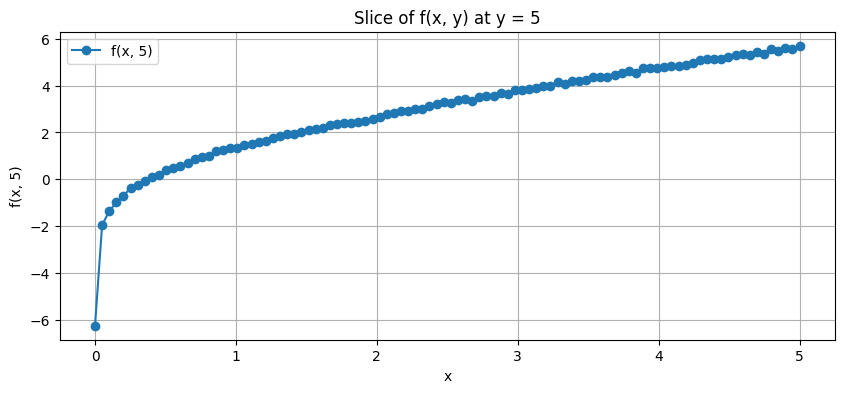

In [ ]:
# Load the file
df = pd.read_csv("Group_1_Data.txt", comment="#", header=None, names=["x", "y", "f"])
df = df.astype(float)

# Filter for y ≈ 5
df_y5 = df[np.isclose(df['y'], 5.0, atol=1e-3)]

# Extract x and f
x = df_y5["x"].values
f = df_y5["f"].values

# Plot
plt.figure(figsize=(10, 4))
plt.plot(x, f, 'o-', label="f(x, 5)")
plt.title("Slice of f(x, y) at y = 5")
plt.xlabel("x")
plt.ylabel("f(x, 5)")
plt.grid(True)
plt.legend()
plt.show()

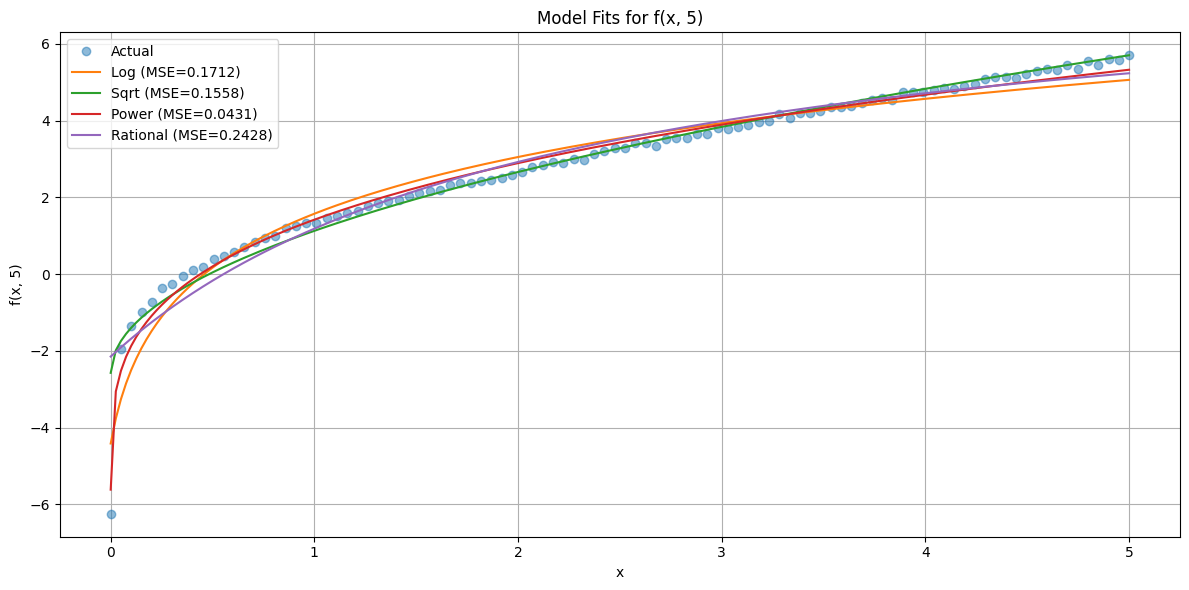

📊 Fit Results Summary:
   Model      MSE                                                           Params
     Log 0.171152 [2.2471934352103884, 0.00013362576087447216, 21.457311308117806]
    Sqrt 0.155797                        [3.7011230985831522, -2.5733471039429436]
   Power 0.043082     [7.035427270950141, 0.27441966020873565, -5.616841544761648]
Rational 0.242792      [-23.13186230534267, 2.1816466348719015, 8.454743305489883]


In [ ]:
# 📊 Fit f(x, 5) using log, sqrt, power, and rational models

# Suppress log warnings for small values
warnings.filterwarnings("ignore")

# Load the file and filter y = 5
df = pd.read_csv("Group_1_Data.txt", comment="#", header=None, names=["x", "y", "f"])
df = df.astype(float)
df_y5 = df[np.isclose(df["y"], 5.0, atol=1e-3)]

x = df_y5["x"].values
f = df_y5["f"].values

# Define candidate functions
def log_model(x, A, B, C):
    return A * np.log(B * x + 1e-5) + C

def sqrt_model(x, A, B):
    return A * np.sqrt(x) + B

def power_model(x, A, p, B):
    return A * x**p + B

def rational_model(x, A, C, B):
    return A / (x + C) + B

# Setup model list
models = {
    "Log": (log_model, [1, 1, 0]),
    "Sqrt": (sqrt_model, [1, 0]),
    "Power": (power_model, [1, 1, 0]),
    "Rational": (rational_model, [1, 1, 0])
}

fit_results = {}

# Plot base
x_fit = np.linspace(min(x), max(x), 200)
plt.figure(figsize=(12, 6))
plt.plot(x, f, 'o', label="Actual", alpha=0.5)

# Fit and store each model
for name, (func, p0) in models.items():
    try:
        params, _ = curve_fit(func, x, f, p0=p0)
        f_pred = func(x, *params)
        mse = mean_squared_error(f, f_pred)
        fit_results[name] = {"params": params, "mse": mse}
        plt.plot(x_fit, func(x_fit, *params), label=f"{name} (MSE={mse:.4f})")
    except Exception as e:
        fit_results[name] = {"params": None, "mse": float("inf")}
        print(f"❌ {name} failed to fit: {e}")

# Finalize plot
plt.title("Model Fits for f(x, 5)")
plt.xlabel("x")
plt.ylabel("f(x, 5)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Print summary table
summary_df = pd.DataFrame({
    "Model": list(fit_results.keys()),
    "MSE": [fit_results[m]["mse"] for m in fit_results],
    "Params": [fit_results[m]["params"] for m in fit_results]
})
print("📊 Fit Results Summary:")
print(summary_df.to_string(index=False))


In [ ]:
# 📦 Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings("ignore")

# Load and filter slice y = 5
df = pd.read_csv("Group_1_Data.txt", comment="#", header=None, names=["x", "y", "f"])
df = df.astype(float)
df_y5 = df[np.isclose(df["y"], 5.0, atol=1e-3)]
x = df_y5["x"].values
f = df_y5["f"].values

# ✅ Custom candidate function form you believe is likely
def hybrid_func(x, A, p, B):
    return A * x**p + B

# 🔁 Brute force grid search
A_vals = np.linspace(6.5, 8.0, 100)  # tighter bounds
p_vals = np.linspace(0.2, 0.3, 100)
B_vals = np.linspace(-6.0, -5.0, 100)

best_mse = float("inf")
best_params = None
best_func = None

for A in A_vals:
    for p in p_vals:
        for B in B_vals:
            try:
                pred = hybrid_func(x, A, p, B)
                mse = mean_squared_error(f, pred)
                if mse < best_mse:
                    best_mse = mse
                    best_params = (A, p, B)
                    best_func = lambda x: hybrid_func(x, A, p, B)
            except:
                continue

# 📈 Plot best fit
plt.figure(figsize=(10, 4))
plt.plot(x, f, 'o', label='Actual')
plt.plot(x, best_func(x), '-', label='Best Fit')
plt.title("🔥 Ultra-Fine Brute Force Fit for f(x, 5)")
plt.xlabel("x")
plt.ylabel("f(x, 5)")
plt.legend()
plt.grid(True)
plt.show()

# 📐 Show best parameters and equation
A, p, B = best_params
print(f"✅ Best Parameters: A={A:.6f}, p={p:.6f}, B={B:.6f}")
print(f"📉 MSE: {best_mse:.10f}")
print(f"🧾 Equation:\nf(x, 5) = {A:.6f} * x^{p:.6f} + {B:.6f}")


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# === Load Data ===
df = pd.read_csv("Group_1_Data.txt", comment="#", header=None, names=["x", "y", "f"])
df = df.astype(float)
df_y5 = df[np.isclose(df["y"], 5.0, atol=1e-3)]
x = df_y5["x"].values
f = df_y5["f"].values

# === Perform FFT ===
N = len(x)
T = x[1] - x[0]  # assume uniform spacing
f_fft = fft(f)
freqs = fftfreq(N, T)

# === Extract dominant frequencies ===
power = np.abs(f_fft)
sorted_idx = np.argsort(power)[::-1]
top_n = 10  # change for more/less terms

# === Get symbolic coefficients ===
a0 = f_fft[0].real / N  # DC term
symbolic_terms = []

for i in range(1, top_n + 1):
    idx = sorted_idx[i]
    amp = 2 * np.abs(f_fft[idx]) / N
    phase = np.angle(f_fft[idx])
    freq = freqs[idx]

    # Format nicely for math output
    term = f"{amp:.4f} * cos({2*np.pi*freq:.4f} * x + {phase:.4f})"
    symbolic_terms.append(term)

# === Display final symbolic expression ===
print("🧠 Approximate Fourier-Based Function:")
print(f"f(x) ≈ {a0:.4f} +")
for term in symbolic_terms:
    print(f"        {term}")


🧠 Approximate Fourier-Based Function:
f(x) ≈ 2.9285 +
        1.9385 * cos(-1.2442 * x + -1.8572)
        1.9385 * cos(1.2442 * x + 1.8572)
        1.0791 * cos(-2.4884 * x + -1.9162)
        1.0791 * cos(2.4884 * x + 1.9162)
        0.7816 * cos(3.7326 * x + 1.9609)
        0.7816 * cos(-3.7326 * x + -1.9609)
        0.6112 * cos(4.9768 * x + 1.9793)
        0.6112 * cos(-4.9768 * x + -1.9793)
        0.5108 * cos(-6.2210 * x + -2.0526)
        0.5108 * cos(6.2210 * x + 2.0526)


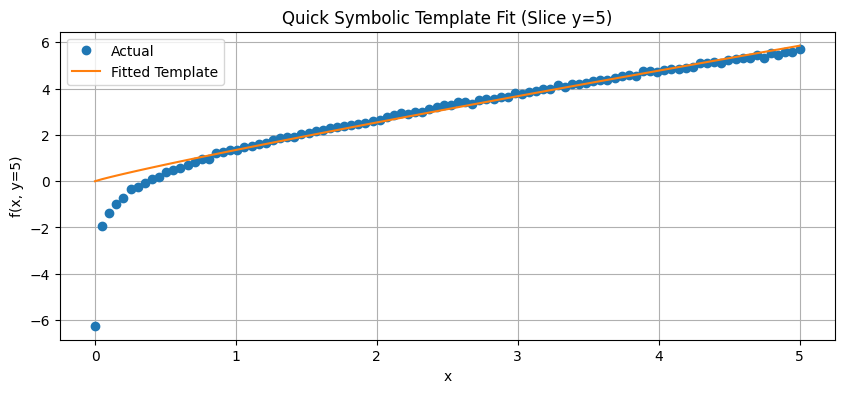


🧠 Best-Fit Function for y=5:
f(x, 5) = 6.8678 * x^0.9117 * sin(1.0657 * 5 + 1.1524)


In [ ]:
from scipy.optimize import curve_fit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load your data
df = pd.read_csv("Group_1_Data.txt", comment="#", header=None, names=["x", "y", "f"])
df = df.astype(float)

# Choose a slice
df_slice = df[np.isclose(df["y"], 5.0, atol=1e-3)]
x = df_slice["x"].values
y = df_slice["y"].values
f_vals = df_slice["f"].values

# Define symbolic template to test
def custom_func(x, a, b, c, d):
    return a * x**b * np.sin(c * 5 + d)  # y = 5 is fixed in this slice

# Fit the function
popt, _ = curve_fit(custom_func, x, f_vals, p0=[1, 1, 1, 1])
f_pred = custom_func(x, *popt)

# Plot result
plt.figure(figsize=(10, 4))
plt.plot(x, f_vals, 'o', label='Actual')
plt.plot(x, f_pred, '-', label='Fitted Template')
plt.title('Quick Symbolic Template Fit (Slice y=5)')
plt.xlabel('x')
plt.ylabel('f(x, y=5)')
plt.legend()
plt.grid(True)
plt.show()

# Display fitted expression
a, b, c, d = popt
print("\n🧠 Best-Fit Function for y=5:")
print(f"f(x, 5) = {a:.4f} * x^{b:.4f} * sin({c:.4f} * 5 + {d:.4f})")


In [ ]:
# 📦 Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings("ignore")

# 📄 Load and clean data
df = pd.read_csv("Group_1_Data.txt", comment='#', header=None, names=["x", "y", "f"])
df = df.astype(float)

# 🎯 Candidate functions to test
def power_law(x, a, b): return a * np.power(x, b)
def log_fn(x, a, b, c): return a * np.log(b * x + c)
def sqrt_fn(x, a, b, c): return a * np.sqrt(b * x + c)
def linear_log(x, a, b, c): return a * x + b * np.log(x + 1e-3) + c
def rational(x, a, b): return a * x / (x + b)

models = {
    "Power Law": (power_law, [1.0, 1.0]),
    "Log": (log_fn, [1.0, 1.0, 1.0]),
    "Sqrt": (sqrt_fn, [1.0, 1.0, 1.0]),
    "Linear+Log": (linear_log, [1.0, 1.0, 0.0]),
    "Rational": (rational, [1.0, 1.0]),
}

# 🔍 Detect unique y-values with full slices
valid_y_values = []
fit_results = {}

for y_val in sorted(df["y"].unique()):
    df_slice = df[np.isclose(df["y"], y_val, atol=1e-5)]
    if len(df_slice) < 10:  # Skip slices with too little data
        continue

    x = df_slice["x"].values
    f = df_slice["f"].values
    valid_y_values.append(y_val)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(x, f, 'o', label=f'f(x, y={y_val:.1f})')

    best_mse = float("inf")
    best_fit = None
    best_label = ""
    best_params = None

    for name, (func, guess) in models.items():
        try:
            params, _ = curve_fit(func, x, f, p0=guess, maxfev=10000)
            f_pred = func(x, *params)
            mse = mean_squared_error(f, f_pred)
            label = f"{name} (MSE={mse:.4f})"
            ax.plot(x, f_pred, label=label)
            if mse < best_mse:
                best_mse = mse
                best_fit = func
                best_label = name
                best_params = params
        except:
            continue

    ax.set_title(f'Model Fits for f(x, y={y_val:.1f})')
    ax.set_xlabel("x")
    ax.set_ylabel("f(x, y)")
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()

    fit_results[y_val] = (best_label, best_mse, best_params)

# 📋 Summary Table
summary = pd.DataFrame([
    {
        "y": y,
        "Best Model": fit_results[y][0],
        "MSE": fit_results[y][1],
        "Params": fit_results[y][2]
    }
    for y in valid_y_values
])

print("📊 Summary of Best Fits per y-slice:")
display(summary)


Output hidden; open in https://colab.research.google.com to view.

🌟 Total MSE over full dataset: 0.020792


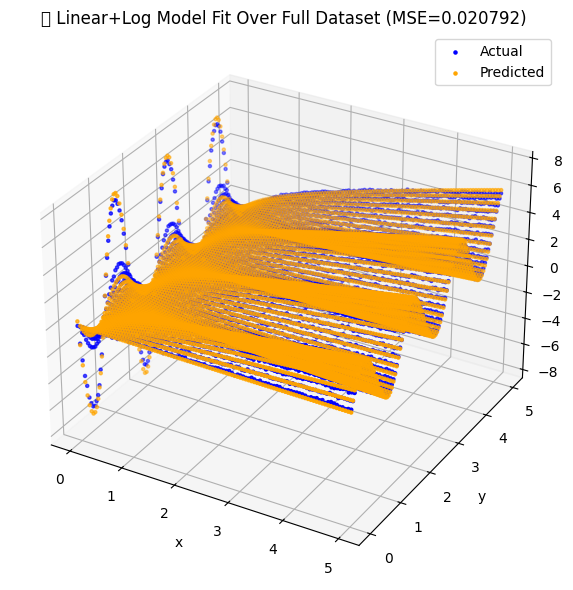

In [ ]:
# 📦 Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline
from sklearn.metrics import mean_squared_error
from mpl_toolkits.mplot3d import Axes3D

# 📄 Load the data
df = pd.read_csv('/content/Group_1_Data.txt', comment='#', header=None, names=['x', 'y', 'f'])
df = df.astype(float)

# 💡 Define the linear + log model
def linear_log_model(x, a, b, c):
    return a * x + b * np.log(x + 1e-6) + c  # small offset to avoid log(0)

# 📊 Fit for slices at unique y-values
unique_ys = sorted(df['y'].unique())
coeffs = []

for y_val in unique_ys:
    subset = df[np.isclose(df['y'], y_val, atol=1e-4)]
    x_slice = subset['x'].values
    f_slice = subset['f'].values
    try:
        popt, _ = curve_fit(linear_log_model, x_slice, f_slice, maxfev=10000)
        coeffs.append([y_val, *popt])
    except RuntimeError:
        continue

coeffs = np.array(coeffs)
ys_fitted = coeffs[:, 0]
a_vals, b_vals, c_vals = coeffs[:, 1], coeffs[:, 2], coeffs[:, 3]

# 📈 Fit splines for each coefficient as a function of y
a_func = UnivariateSpline(ys_fitted, a_vals, s=0.01)
b_func = UnivariateSpline(ys_fitted, b_vals, s=0.01)
c_func = UnivariateSpline(ys_fitted, c_vals, s=0.01)

# 🧠 Final composite function f(x, y)
def final_model(x, y):
    return a_func(y) * x + b_func(y) * np.log(x + 1e-6) + c_func(y)

# 🧪 Predict and compare
x_all = df['x'].values
y_all = df['y'].values
f_actual = df['f'].values
f_predicted = final_model(x_all, y_all)

# 📉 Compute MSE
mse_total = mean_squared_error(f_actual, f_predicted)
print(f"🌟 Total MSE over full dataset: {mse_total:.6f}")

# 📊 Plot comparison in 3D
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x_all, y_all, f_actual, color='blue', s=5, label='Actual')
ax.scatter(x_all, y_all, f_predicted, color='orange', s=5, label='Predicted')
ax.set_title(f'📊 Linear+Log Model Fit Over Full Dataset (MSE={mse_total:.6f})')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
ax.legend()
plt.tight_layout()
plt.show()


✅ Iter 0 New Best MSE: 1.227983
🔁 Refined MSE: 0.367679
🔁 Refined MSE: 0.002317


<ipython-input-4-a7d6ef7fb6a2>:36: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(best_model, X, f_actual, p0=initial_guess, maxfev=50000)
<ipython-input-4-a7d6ef7fb6a2>:36: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(best_model, X, f_actual, p0=initial_guess, maxfev=50000)
<ipython-input-4-a7d6ef7fb6a2>:36: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(best_model, X, f_actual, p0=initial_guess, maxfev=50000)
<ipython-input-4-a7d6ef7fb6a2>:36: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(best_model, X, f_actual, p0=initial_guess, maxfev=50000)
<ipython-input-4-a7d6ef7fb6a2>:36: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(best_model, X, f_actual, p0=initial_guess, maxfev=50000)
<ipython-input-4-a7d6ef7fb6a2>:36: OptimizeWarning: Covariance of the parameters coul

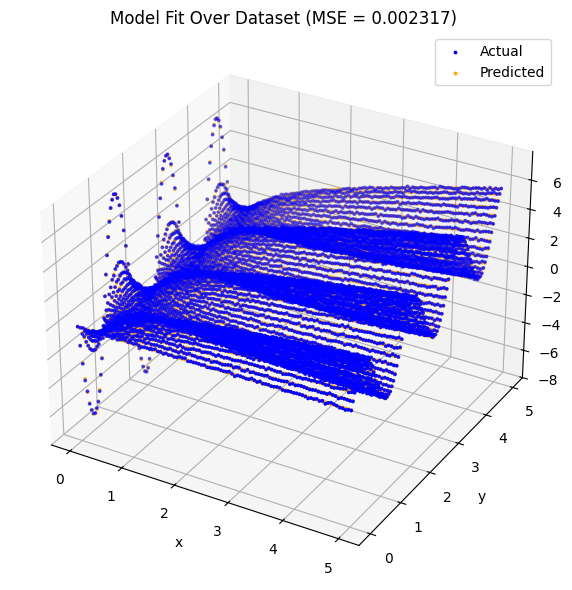

Fitted Function:
f(x, y) = 0.5007 * ln(0.0000 + 0.0023*x + -0.0000*y + 3.9811*x^2 + 0.0000*y^2 + 0.0016*x*y) * sin(3.1433 + -0.0000*x + -4.0009*y + -0.0001*x^2 + 0.0001*y^2 + 0.0003*x*y) + 0.1428*x*y + 0.0008
Final MSE: 0.0023173343047865878


In [4]:
# Upload your data file manually via the file panel in Google Colab before running this
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error

# Load data (adjust filename if needed)
df = pd.read_csv("Group_1_Data.txt", comment="#", header=None, names=["x", "y", "f"])
df = df.astype(float)

# Extract variables
x = df["x"].values
y = df["y"].values
f_actual = df["f"].values
X = np.vstack((x, y))

# Professor-inspired nonlinear model
def symbolic_model(X, *params):
    x, y = X
    ln_term = (params[1] + params[2]*x + params[3]*y + params[4]*x**2 + params[5]*y**2 + params[6]*x*y)
    sin_term = (params[7] + params[8]*x + params[9]*y + params[10]*x**2 + params[11]*y**2 + params[12]*x*y)
    with np.errstate(divide='ignore', invalid='ignore'):
        ln_term = np.where(ln_term > 0, np.log(ln_term), 0)
    return params[0] * ln_term * np.sin(sin_term) + params[13]*x*y + params[14]

# Smart search loop
def run_fit(x, y, f_actual, iterations=300, refinement_loops=10, perturb_scale=0.1):
    best_mse = float("inf")
    best_params = None
    best_model = symbolic_model

    for i in range(iterations):
        initial_guess = np.random.uniform(-1, 1, size=15)
        try:
            popt, _ = curve_fit(best_model, X, f_actual, p0=initial_guess, maxfev=50000)
            f_pred = best_model(X, *popt)
            mse = mean_squared_error(f_actual, f_pred)

            if mse < best_mse:
                best_mse = mse
                best_params = popt
                print(f"✅ Iter {i} New Best MSE: {best_mse:.6f}")

                # Refine search locally
                for _ in range(refinement_loops):
                    new_guess = best_params + np.random.normal(0, perturb_scale, size=15)
                    try:
                        refined_popt, _ = curve_fit(best_model, X, f_actual, p0=new_guess, maxfev=50000)
                        refined_pred = best_model(X, *refined_popt)
                        refined_mse = mean_squared_error(f_actual, refined_pred)
                        if refined_mse < best_mse:
                            best_mse = refined_mse
                            best_params = refined_popt
                            print(f"🔁 Refined MSE: {best_mse:.6f}")
                    except:
                        continue
        except:
            continue

    return best_params, best_mse, best_model

# Fit the model
best_params, best_mse, model = run_fit(x, y, f_actual)

# Plot result
f_pred = model(X, *best_params)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, f_actual, color='blue', label='Actual', s=3)
ax.scatter(x, y, f_pred, color='orange', label='Predicted', s=3)
ax.set_title(f"Model Fit Over Dataset (MSE = {best_mse:.6f})")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x, y)")
ax.legend()
plt.tight_layout()
plt.show()

# Format final equation
def format_equation(params):
    ln = f"({params[1]:.4f} + {params[2]:.4f}*x + {params[3]:.4f}*y + {params[4]:.4f}*x^2 + {params[5]:.4f}*y^2 + {params[6]:.4f}*x*y)"
    sin = f"({params[7]:.4f} + {params[8]:.4f}*x + {params[9]:.4f}*y + {params[10]:.4f}*x^2 + {params[11]:.4f}*y^2 + {params[12]:.4f}*x*y)"
    return f"f(x, y) = {params[0]:.4f} * ln{ln} * sin{sin} + {params[13]:.4f}*x*y + {params[14]:.4f}"

print("Fitted Function:")
print(format_equation(best_params))
print("Final MSE:", best_mse)


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import mean_squared_error

# Load your data
df = pd.read_csv("/mnt/data/Group_1_Data.txt", comment="#", header=None, names=["x", "y", "f"])
df = df.astype(float)
x = df["x"].values
y = df["y"].values
f_actual = df["f"].values

# Build input grid for visualization
X, Y = np.meshgrid(np.unique(x), np.unique(y))
Z_actual = f_actual.reshape(len(np.unique(y)), len(np.unique(x)))

# Define fitted function from your provided coefficients
def fitted_function(x, y):
    log_term = 0.0000 + 0.0023*x + -0.0000*y + 3.9811*x**2 + 0.0000*y**2 + 0.0016*x*y
    sin_term = 3.1433 + -0.0000*x + -4.0009*y + -0.0001*x**2 + 0.0001*y**2 + 0.0003*x*y

    # Prevent log domain error
    log_term = np.maximum(log_term, 1e-8)

    return 0.5007 * np.log(log_term) * np.sin(sin_term) + 0.1428 * x * y + 0.0008

# Predict using the function
f_pred = fitted_function(x, y)
Z_pred = f_pred.reshape(len(np.unique(y)), len(np.unique(x)))

# Compute error
mse = mean_squared_error(f_actual, f_pred)

# Plot 3D fit vs actual
fig = plt.figure(figsize=(14, 6))

# 3D Comparison
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(x, y, f_actual, c='blue', s=5, label='Actual')
ax1.scatter(x, y, f_pred, c='orange', s=5, label='Predicted')
ax1.set_title(f"3D Fit vs Actual (MSE = {mse:.6f})")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("f(x, y)")
ax1.legend()

# Residual Heatmap
residuals = Z_actual - Z_pred
ax2 = fig.add_subplot(1, 2, 2)
heatmap = ax2.imshow(residuals, cmap='coolwarm', origin='lower', extent=[x.min(), x.max(), y.min(), y.max()])
ax2.set_title("Residuals Heatmap")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
plt.colorbar(heatmap, ax=ax2, label="Residual (Actual - Predicted)")

plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/Group_1_Data.txt'